In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../Raw/Market capitalization of listed domestic companies/API_CM.MKT.LCAP.CD_DS2_en_csv_v2_999.csv", skiprows=4)
df

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,6.198511e+10,7.182296e+10,6.471762e+10,6.884437e+10,NaN,NaN,NaN,NaN
4,Angola,AGO,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,"Yemen, Rep.",YEM,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
263,South Africa,ZAF,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,1.230977e+12,8.653276e+11,1.056341e+12,1.051529e+12,1.143003e+12,1.171748e+12,1.025827e+12,9.856974e+11,NaN,NaN
264,Zambia,ZMB,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2.716490e+09,4.034770e+09,4.037230e+09,3.456230e+09,7.765130e+09,NaN,NaN


In [3]:
yr_cols = [col for col in df.columns if col.startswith('20') or col.startswith('19')]
df[yr_cols] = df[yr_cols].apply(pd.to_numeric, errors='coerce')

In [4]:
# Melt the DataFrame to long format
# 'Country Name', 'Country Code', 'Indicator Name', 'Indicator Code' are id_vars
id_vars = ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code']
df_long = df.melt(id_vars=id_vars, value_vars=yr_cols, var_name='Year', value_name='Market Cap')
df_long

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Market Cap
0,Aruba,ABW,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,1960,NaN
1,Africa Eastern and Southern,AFE,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,1960,NaN
2,Afghanistan,AFG,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,1960,NaN
3,Africa Western and Central,AFW,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,1960,NaN
4,Angola,AGO,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,1960,NaN
...,...,...,...,...,...,...
17551,Kosovo,XKX,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,2025,NaN
17552,"Yemen, Rep.",YEM,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,2025,NaN
17553,South Africa,ZAF,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,2025,NaN
17554,Zambia,ZMB,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,2025,NaN


In [5]:
df_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17556 entries, 0 to 17555
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    17556 non-null  object 
 1   Country Code    17556 non-null  object 
 2   Indicator Name  17556 non-null  object 
 3   Indicator Code  17556 non-null  object 
 4   Year            17556 non-null  object 
 5   Market Cap      3697 non-null   float64
dtypes: float64(1), object(5)
memory usage: 823.1+ KB


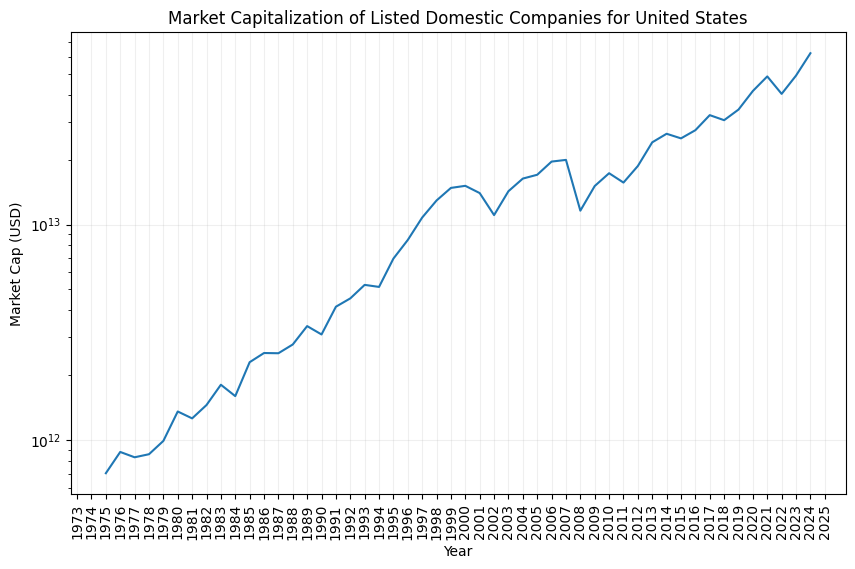

In [8]:
# Inspect norway
nor = df_long[df_long['Country Name'] == 'United States'].sort_values('Year')
plt.figure(figsize=(10, 6))
sns.lineplot(data=nor, x='Year', y="Market Cap")
plt.title('Market Capitalization of Listed Domestic Companies for United States')
plt.xlabel('Year')
plt.ylabel('Market Cap (USD)')
plt.xticks(rotation=90)
plt.grid(alpha=0.2)
plt.yscale("log")
plt.show()

In [ ]:
# Add iso3 code as the country code
df_long["iso3"] = df_long["Country Code"]

In [ ]:
df_long[df_long["iso3"]=="SWE"].groupby("iso3")["Market Cap"].mean()

iso3
SWE    1.164924e+11
Name: Market Cap, dtype: float64

In [ ]:
# Export to clean csv
df_long.to_csv("../Clean/market_cap.csv", index=False)